# Chapter 1 — The geometry hidden in every model

*Companion notebook to **The Learned Kernel**, Ch. 1. Run top to bottom.*

A linear model, a tree and a nearest-neighbor rule give three different answers for
the same house. The point of this chapter is that the three answers are the **same
kind of computation** — a weighted vote over training labels — and that the weights
are a *geometry*: a statement of which points each model treats as near. This
notebook lets you **see and touch** that geometry on the running data.

**What you will do here**
1. Verify, on the data, that ridge / tree / k-NN are each $\hat y(x)=\sum_i w_i(x)\,y_i$.
2. Read the three weight functions and *look* at their shapes over the map.
3. **Move the query and turn the knobs** ($k$, tree depth, ridge $\lambda$) and watch
   the geometry change.
4. Work the chapter exercises with solutions one click away.

**The frame this book uses everywhere** — *what is learned · how it is scored · what you
read off it.* In this chapter the geometry is mostly **fixed in advance**, not learned;
that is the habit the book breaks. Here we only establish that the object exists (the
weights *are* a geometry) and that it is inspectable (you can read which cases mattered).
The tree gives the first taste of a geometry genuinely *fit* from data.

## Setup

Install the companion package once (`pip install -e .` from the repo root, or
`pip install "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"`).
The notebook imports the **same** functions the book figures are generated from, so its
numbers and figure match the printed chapter exactly — nothing here is re-implemented.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

from lkbook import load_california, load_taiwan, set_style, SIGNED_CMAP, POS_CMAP
from lkbook.chapters import ch01 as ch1

set_style()
cal = load_california()
print(f"California Housing: {cal.n} train rows, {cal.d} features; "
      f"target in units of {cal.target_unit}")
print("features:", cal.names)

California Housing: 16512 train rows, 8 features; target in units of $100,000
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 1.1  A prediction is a weighted vote

Hold out one Los Angeles census block and predict its median value three ways. Each
model returns a number — and each number is an average of training labels with
*different* weights. We fit all three, then **assert on the data** that every one
satisfies $\hat y(x)=\sum_i w_i(x)\,y_i$.

In [2]:
q = 7                                   # the held-out block we will explain
x = cal.Xte[q]
print("query block:", {n: round(float(cal.Xte_raw[q, j]), 2)
                       for j, n in enumerate(cal.names)})

ridge, tree, knn = ch1.fit_models(cal)
weights = {
    "ridge": ch1.ridge_weights(cal.Xtr, x),
    "tree": ch1.tree_weights(tree, cal.Xtr, x),
    "k-NN": ch1.knn_weights(knn, cal.Xtr, x),
}
preds = {
    "ridge": float(ridge.predict(np.append(x, 1.0)[None])[0]),
    "tree": float(tree.predict(x[None])[0]),
    "k-NN": float(knn.predict(x[None])[0]),
}

rows = []
for m in ("ridge", "tree", "k-NN"):
    w = weights[m]
    vote = ch1.assert_weighted_vote(w, cal.ytr, preds[m])   # raises if identity fails
    rows.append({"model": m, "prediction ($100k)": round(preds[m], 4),
                 "sum w_i y_i": round(vote, 4), "sum w_i": round(float(w.sum()), 3),
                 "# cases weighted": int((w != 0).sum())})
pd.DataFrame(rows).set_index("model")

query block: {'MedInc': 5.93, 'HouseAge': 37.0, 'AveRooms': 5.83, 'AveBedrms': 0.97, 'Population': 794.0, 'AveOccup': 2.34, 'Latitude': 34.17, 'Longitude': -118.43}


,prediction ($100k),sum w_i y_i,sum w_i,# cases weighted
model,,,,
ridge,3.0565,3.0565,1.0,16512
tree,3.6990,3.6990,1.0,328
k-NN,3.2082,3.2082,1.0,30


The `sum w_i y_i` column reproduces each model's own prediction to machine precision —
the weighted-vote identity is not a metaphor, it holds on the data. Notice the last
column: ridge weights **all 16,512** blocks, the tree only its leaf of a few hundred,
k-NN exactly 30. Three numbers within \$64k of each other, built from completely
different sets of cases.

## 1.2  Three geometries on one dataset

Look at *which* cases each model leaned on. Below are the five training blocks with the
largest $|w_i(x)|$ for each model — the cases that mattered.

In [3]:
for m in ("ridge", "tree", "k-NN"):
    print(f"\n=== {m}: top-5 cases by |w_i| ===")
    display(pd.DataFrame(ch1.top_neighbors(weights[m], cal.ytr, cal.names, cal.Xtr_raw)))


=== ridge: top-5 cases by |w_i| ===


,w,y,MedInc,HouseAge,AveRooms
0,-0.000725,1.34400,2.5729,14.0,5.270497
1,-0.000693,1.18800,2.3087,11.0,5.364518
2,-0.000624,1.62500,4.6250,34.0,132.533333
3,0.000612,5.00001,15.0001,52.0,7.958333
4,0.000607,5.00001,15.0001,52.0,8.710145



=== tree: top-5 cases by |w_i| ===


,w,y,MedInc,HouseAge,AveRooms
0,0.003049,3.413,5.6431,52.0,5.817352
1,0.003049,4.359,6.0433,20.0,6.470756
2,0.003049,2.938,6.1731,26.0,8.146497
3,0.003049,2.094,6.0000,20.0,6.007707
4,0.003049,3.382,5.5798,33.0,6.418573



=== k-NN: top-5 cases by |w_i| ===


,w,y,MedInc,HouseAge,AveRooms
0,0.033333,2.396,5.6200,36.0,6.228571
1,0.033333,2.183,5.5581,36.0,6.118467
2,0.033333,3.599,5.6152,38.0,5.989510
3,0.033333,2.908,6.0648,36.0,5.898374
4,0.033333,3.307,5.7422,37.0,5.836449


Ridge's heavy cases are **signed** and extreme — low-income blocks pulling the estimate
down, the value-capped richest blocks pulling it up, drawn from across the whole state.
The tree's and k-NN's are all **positive and local**: nearby blocks that look like the
query. Now *see* the three shapes. The figure below — the same one printed in the book —
shows the influence each geometry would assign to a hypothetical block at every location:
ridge a smooth signed gradient, the tree a hard axis-aligned box, k-NN a round disk.

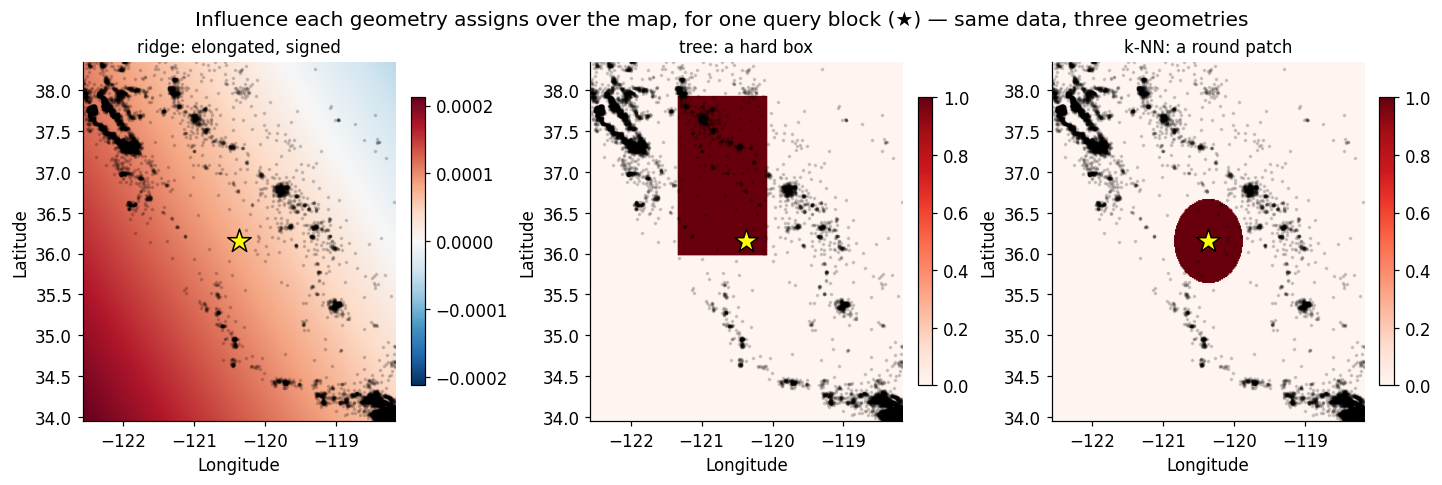

In [4]:
ch1.make_influence_figure(cal)
plt.show()

### Touch the geometry

Move the query (longitude/latitude) and turn the three knobs. Watch how each geometry
responds: the **box** grows and shrinks with tree depth, the **disk** with $k$, and the
ridge **gradient** barely cares about $\lambda$ — because ridge's reach is global by
construction, not a tunable locality. This is the chapter's claim made tactile: each
model's notion of "near" is a different object, and right now each is *fixed by a knob
you set*, not learned from the target.

In [5]:
from ipywidgets import interact, FloatSlider, IntSlider

# geographic (lon, lat) models, prepared once
_jl, _jL = cal.col("Longitude"), cal.col("Latitude")
_G = cal.Xtr_raw[:, [_jl, _jL]]
_scg = StandardScaler().fit(_G)
_Gs = _scg.transform(_G)


def explore(lon=-119.7, lat=36.1, k=30, depth=6, log10_lambda=0.0, win=2.5, res=140):
    x2 = _scg.transform([[lon, lat]])[0]
    lon_g = np.linspace(lon - win, lon + win, res)
    lat_g = np.linspace(lat - win, lat + win, res)
    LON, LAT = np.meshgrid(lon_g, lat_g)
    grid = _scg.transform(np.c_[LON.ravel(), LAT.ravel()])
    rf, tf, kf = ch1.geo_influence_fields(_Gs, cal.ytr, x2, grid,
                                          depth=depth, k=k, lam=10.0 ** log10_lambda)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
    panels = [(rf, f"ridge (λ={10.0**log10_lambda:.3g}): signed", SIGNED_CMAP, True),
              (tf, f"tree (depth={depth}): a box", POS_CMAP, False),
              (kf, f"k-NN (k={k}): a disk", POS_CMAP, False)]
    for ax, (F, title, cmap, signed) in zip(axes, panels):
        F = F.reshape(LON.shape)
        kw = dict(extent=[lon_g[0], lon_g[-1], lat_g[0], lat_g[-1]],
                  origin="lower", aspect="auto", cmap=cmap)
        if signed:
            v = np.abs(F).max() or 1.0
            kw.update(vmin=-v, vmax=v)
        ax.imshow(F, **kw)
        ax.scatter([lon], [lat], marker="*", s=220, c="yellow", edgecolors="k", zorder=5)
        ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.show()


interact(explore,
         lon=FloatSlider(min=-124.0, max=-114.5, step=0.2, value=-119.7),
         lat=FloatSlider(min=32.6, max=41.9, step=0.2, value=36.1),
         k=IntSlider(min=5, max=300, step=5, value=30),
         depth=IntSlider(min=1, max=12, step=1, value=6),
         log10_lambda=FloatSlider(min=-3, max=3, step=0.5, value=0.0,
                                  description="log10 λ"));

interactive(children=(FloatSlider(value=-119.7, description='lon', max=-114.5, min=-124.0, step=0.2), FloatSli…

## 1.3  The kernel names the weights

Each weight $w_i(x)$ measures one thing: how much training case $i$ counts at $x$. Call
that $k(x,x_i)$, the **kernel**. The tree and k-NN are then the *normalized-kernel
smoother* $w_i(x)=k(x,x_i)/\sum_r k(x,x_r)$ with a hard $\{0,1\}$ kernel. Verify it: the
tree weights equal the normalized leaf-indicator kernel exactly.

In [6]:
leaf_x = tree.apply(x[None])[0]
k_hard = (tree.apply(cal.Xtr) == leaf_x).astype(float)     # k(x, x_i) = 1{same leaf}
w_from_kernel = k_hard / k_hard.sum()                      # normalized smoother
print("max |tree_weights - normalized leaf kernel| =",
      float(np.abs(weights["tree"] - w_from_kernel).max()))

# ridge is the linear kernel k(x, x_i) = x^T M x_i with M = (X^T X + lam I)^{-1}
Xb = np.hstack([cal.Xtr, np.ones((cal.n, 1))]); xb = np.append(x, 1.0)
M = np.linalg.inv(Xb.T @ Xb + ch1.LAM * np.eye(Xb.shape[1]))
w_linear = xb @ M @ Xb.T
print("max |ridge_weights - linear-kernel weights| =",
      float(np.abs(weights["ridge"] - w_linear).max()))

max |tree_weights - normalized leaf kernel| = 0.0
max |ridge_weights - linear-kernel weights| = 2.0057740190981832e-18


Both are zero to machine precision. So all three models are kernels — the only reason
ridge does not *look* like a smoother on the raw inputs is that its similarity lives in
feature space (the map $\varphi$), which Chapter 2 makes explicit. Choosing a model is,
underneath, choosing a kernel — which raises the book's question: where should the
kernel come from?

## 1.4  Chosen versus discovered

The classical habit *fixes* the kernel. But the geometry is the thing we want to learn,
so it should come from the data. One of our three models already broke the habit: the
tree's box was **fit to the labels** by the splitting rule. The other two did not — k-NN
fixes a round ball and only tunes its radius. Watch the same query's answer swing as we
change k-NN's fixed radius: a *choice*, not a discovery.

In [7]:
ks = [1, 5, 15, 30, 60, 120, 300, 1000]
swing = [{"k": kk,
          "k-NN prediction ($100k)": round(float(
              KNeighborsRegressor(n_neighbors=kk).fit(cal.Xtr, cal.ytr)
              .predict(x[None])[0]), 3)} for kk in ks]
pd.DataFrame(swing).set_index("k")

,k-NN prediction ($100k)
k,
1,2.380
5,2.840
15,3.333
30,3.208
60,3.061
120,3.176
300,2.993
1000,2.887


The prediction drifts from a noisy single-neighbor value toward the global mean as $k$
grows. Nothing in the data told us which $k$ is right; we *chose* it. The rest of the
book is about replacing that choice with a geometry **learned and scored** on the data —
starting with the gradient-boosted forest (Ch. 4) and the Gaussian process, which scores
its own geometry through the marginal likelihood (Ch. 5).

## A second target: Taiwan Credit

The weighted-vote identity is a fact about the *form* of these predictors, not the
target. Here it is on a binary default label — the score is the weighted fraction of
similar past applicants who defaulted.

In [8]:
tw = load_taiwan()
xa = tw.Xte[3]
print("applicant:", {n: int(tw.Xte_raw[3, j]) for j, n in enumerate(tw.names[:6])})
_, tw_tree, tw_knn = ch1.fit_models(tw)
for m, mdl, w in [("tree", tw_tree, ch1.tree_weights(tw_tree, tw.Xtr, xa)),
                  ("k-NN", tw_knn, ch1.knn_weights(tw_knn, tw.Xtr, xa))]:
    p = float(mdl.predict(xa[None])[0])
    ch1.assert_weighted_vote(w, tw.ytr, p)
    print(f"  {m:5s} default score = {p:.3f}  (= weighted fraction of "
          f"{int((w!=0).sum())} similar applicants who defaulted)")

applicant: {'LIMIT_BAL': 100000, 'SEX': 1, 'EDUCATION': 2, 'MARRIAGE': 1, 'AGE': 42, 'PAY_0': 0}


  tree  default score = 0.082  (= weighted fraction of 8302 similar applicants who defaulted)
  k-NN  default score = 0.100  (= weighted fraction of 30 similar applicants who defaulted)


## Exercises

Fill in each `# TODO`; the solution is one click away. (Solutions assume the variables
defined above.)

**(easy)** Express ridge in the $\hat y(x)=\sum_i w_i(x)\,y_i$ form and confirm the
weights need not be nonnegative. Compute the fraction of ridge weights that are
negative for our query, and the most negative one.

In [9]:
# TODO: using `weights["ridge"]`, compute (frac_negative, most_negative_weight)
frac_negative = None
most_negative = None
print(frac_negative, most_negative)

None None


<details><summary>Solution</summary>

```python
w = weights["ridge"]
frac_negative = float((w < 0).mean())
most_negative = float(w.min())
print(f"{frac_negative:.1%} of ridge weights are negative; min weight = {most_negative:.2e}")
```
Ridge spreads signed influence across the whole training set — a global, not local,
geometry.
</details>

**(medium)** Show $k$-NN is the limit of a hard-threshold kernel
$k_h(x,x')=\mathbf 1\{\lVert x-x'\rVert\le h\}$. For our query, find the radius $h$ in
standardized feature space that captures exactly $k=30$ neighbors, build the normalized
threshold-kernel weights, and check they equal `weights["k-NN"]`.

In [10]:
# TODO: find h (distance to the 30th neighbor) and build normalized 1{dist<=h} weights;
#       compare to weights["k-NN"]
h = None

<details><summary>Solution</summary>

```python
d_all = np.linalg.norm(cal.Xtr - x, axis=1)
h = np.sort(d_all)[ch1.K - 1]              # distance to the 30th neighbor
kh = (d_all <= h).astype(float)
w_thr = kh / kh.sum()
print("max |w_thr - knn_weights| =", float(np.abs(w_thr - weights["k-NN"]).max()))
```
As $h\to 0$ each $w_i(x)$ concentrates on the single nearest case (1-NN); growing $h$
widens the ball. The radius is the bandwidth — a *chosen* scale.
</details>

**(⋆)** Construct two regressors with (near-)identical predictions on the query but
visibly different weight functions. Use ridge and k-NN: report both predictions and the
correlation between their weight vectors. Conclude that predictions do not identify the
geometry — the point Chapter 3 makes precise.

In [11]:
# TODO: compare preds["ridge"] vs preds["k-NN"], and np.corrcoef of the two weight vectors
weight_correlation = None

<details><summary>Solution</summary>

```python
gap = abs(preds["ridge"] - preds["k-NN"])
weight_correlation = float(np.corrcoef(weights["ridge"], weights["k-NN"])[0, 1])
print(f"prediction gap = ${gap*100:.0f}k;  weight-vector correlation = {weight_correlation:.3f}")
```
Close predictions, nearly uncorrelated weights: the same answer comes from different
geometries. The fit does not pin down the geometry — Chapter 3 makes this identifiability
question precise.
</details>

---
*Companion to Chapter 1 of **The Learned Kernel**. The weight functions, the influence
fields and the figure come from `lkbook.chapters.ch01` + `lkbook` — the same code the
printed figure is generated from.*